# Vision Benchmark Analysis

This notebook contains the requested vision figures, plus a move-benchmark diagnostics section:
1. Model accuracy comparison (with external MMMU_val side-by-side)
2. SAN and piece placement consistency
3. Mean confidence by correctness
4. Move benchmark diagnostics (completion, CP-loss by cue, and move-style distribution)


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

data_dir = Path('data/benchmark_vision')
predictions_path = data_dir / 'vision_predicitions.csv'

df = pd.read_csv(predictions_path)
df['failed'] = df['error'].notna() & (df['error'].astype(str).str.strip() != '')
df['model_display'] = df['model'].str.replace(r'^Qwen/', '', regex=True)

benchmark_model_order = [
    'Qwen2.5-VL-72B-Instruct',
    'Qwen3-VL-30B-A3B-Instruct',
    'gpt-4o',
    'gpt-5.3-chat',
]

print('Rows:', len(df))
print('Models:', sorted(df['model_display'].unique().tolist()))
print('Samples:', df['sample_id'].nunique())


Rows: 200
Models: ['Qwen2.5-VL-72B-Instruct', 'Qwen3-VL-30B-A3B-Instruct', 'gpt-4o', 'gpt-5.3-chat']
Samples: 50


## 1) Model Accuracy Comparison

,model_display,exact_move_accuracy,exact_piece_placement_accuracy,mmmu_accuracy,mathvista_accuracy
0,Qwen2.5-VL-72B-Instruct,0.02,0.02,0.702,0.748
1,Qwen3-VL-30B-A3B-Instruct,0.00,0.00,0.742,0.801
2,gpt-4o,0.04,0.04,0.703,0.638
3,gpt-5.3-chat,0.42,0.42,0.738,NaN


Exact move accuracy and exact piece placement accuracy are identical for this dataset.


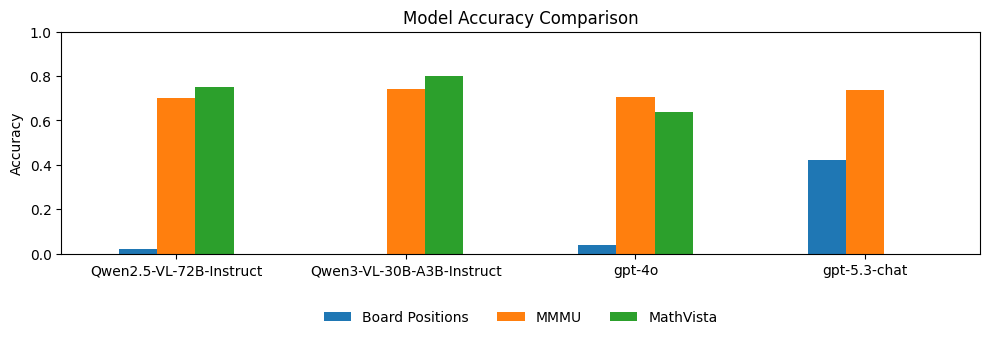

In [2]:
acc = (
    df.groupby('model_display', as_index=False)
    .agg(
        exact_move_accuracy=('exact_move_match', 'mean'),
        exact_piece_placement_accuracy=('exact_piece_placement_match', 'mean'),
    )
)

model_order = [
    model
    for model in benchmark_model_order
    if model in set(acc['model_display'].astype(str))
]

acc['model_display'] = pd.Categorical(
    acc['model_display'],
    categories=model_order,
    ordered=True,
)
acc = acc.sort_values('model_display').reset_index(drop=True)

# External benchmarks chosen: MMMU and MathVista (higher is better).
# Values come from published benchmark summaries in project/model pages.
external_mmmu = {
    'Qwen2.5-VL-72B-Instruct': 70.2,
    'Qwen3-VL-30B-A3B-Instruct': 74.2,
    'gpt-4o': 70.3,
    # Proxy mapping: gpt-5.3-chat -> published gpt-5.3-instant score.
    'gpt-5.3-chat': 73.8,
}

external_mathvista = {
    'Qwen2.5-VL-72B-Instruct': 74.8,
    'Qwen3-VL-30B-A3B-Instruct': 80.1,
    'gpt-4o': 63.8,
}

acc['mmmu_accuracy'] = acc['model_display'].astype(str).map(external_mmmu) / 100.0
acc['mathvista_accuracy'] = acc['model_display'].astype(str).map(external_mathvista) / 100.0

display(acc)

if (df['exact_move_match'] == df['exact_piece_placement_match']).all():
    print('Exact move accuracy and exact piece placement accuracy are identical for this dataset.')

plot_df = acc.set_index('model_display')[
    ['exact_move_accuracy', 'mmmu_accuracy', 'mathvista_accuracy']
]
plot_df = plot_df.reindex(model_order)
plot_df.index.name = None
ax = plot_df.plot(kind='bar', figsize=(10, 4))
ax.set_title('Model Accuracy Comparison')
ax.set_ylabel('Accuracy')
ax.set_xlabel('')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=0)
ax.legend(['Board Positions', 'MMMU', 'MathVista'], loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


## 2) SAN and Piece Placement Consistency

,model_display,consistency_label,count,rate
0,Qwen2.5-VL-72B-Instruct,Inconsistent: SAN and placement not aligned,50,1.00
1,Qwen3-VL-30B-A3B-Instruct,Inconsistent: SAN and placement not aligned,50,1.00
3,gpt-4o,Inconsistent: SAN and placement not aligned,47,0.94
2,gpt-4o,Consistent: SAN and placement align,3,0.06
4,gpt-5.3-chat,Consistent: SAN and placement align,40,0.80
5,gpt-5.3-chat,Inconsistent: SAN and placement not aligned,10,0.20


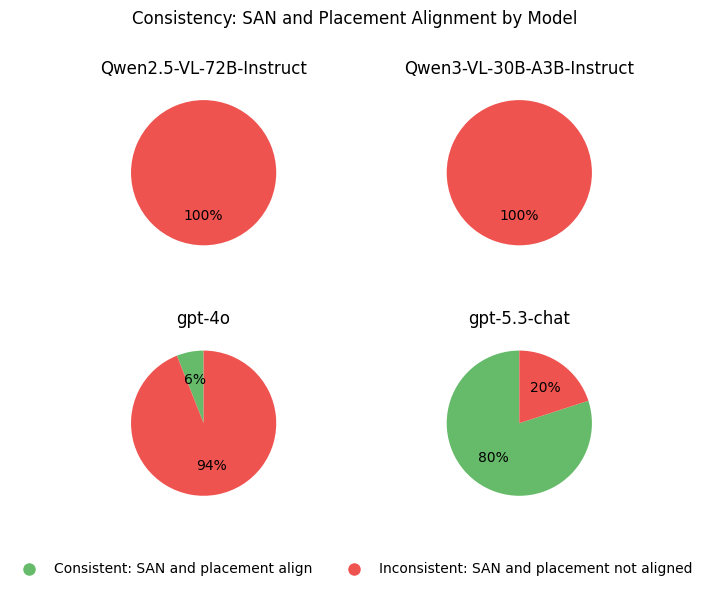

In [3]:
consistency_df = df.copy()
consistency_df['consistency_label'] = consistency_df['webapp_selected_path'].map({
    'san_and_placement_agree': 'Consistent: SAN and placement align',
}).fillna('Inconsistent: SAN and placement not aligned')

consistency_counts = (
    consistency_df.groupby(['model_display', 'consistency_label'], as_index=False)
    .size()
    .rename(columns={'size': 'count'})
)
consistency_counts['rate'] = (
    consistency_counts['count']
    / consistency_counts.groupby('model_display')['count'].transform('sum')
)

model_order = [
    model
    for model in benchmark_model_order
    if model in set(consistency_counts['model_display'].astype(str))
]
consistency_counts['model_display'] = pd.Categorical(
    consistency_counts['model_display'],
    categories=model_order,
    ordered=True,
)

display(
    consistency_counts[
        ['model_display', 'consistency_label', 'count', 'rate']
    ].sort_values(['model_display', 'count'], ascending=[True, False])
)

models = model_order
labels_order = [
    'Consistent: SAN and placement align',
    'Inconsistent: SAN and placement not aligned',
]
colors = {
    'Consistent: SAN and placement align': '#66BB6A',
    'Inconsistent: SAN and placement not aligned': '#EF5350',
}

fig, axes = plt.subplots(2, 2, figsize=(7.2, 6))
axes = axes.flatten()

for idx, model_name in enumerate(models):
    ax = axes[idx]
    model_rows = consistency_counts[consistency_counts['model_display'] == model_name]
    values = []
    pie_colors = []
    for label in labels_order:
        row = model_rows[model_rows['consistency_label'] == label]
        if row.empty:
            continue
        values.append(float(row['count'].iloc[0]))
        pie_colors.append(colors[label])

    if values:
        ax.pie(values, autopct='%1.0f%%', startangle=90, colors=pie_colors)
    ax.set_title(model_name)

for idx in range(len(models), len(axes)):
    axes[idx].axis('off')

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[label], markersize=10)
    for label in labels_order
]

fig.legend(
    legend_handles,
    labels_order,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.08),
    ncol=2,
    frameon=False,
)
fig.suptitle('Consistency: SAN and Placement Alignment by Model')
fig.subplots_adjust(left=0.06, right=0.96, top=0.86, bottom=0.14, wspace=-0.05, hspace=0.38)
plt.show()


## 3) Mean Confidence by Correctness

,model_display,exact_move_match,mean_confidence,samples,correctness
1,Qwen2.5-VL-72B-Instruct,True,1.000000,1,Correct
0,Qwen2.5-VL-72B-Instruct,False,0.991379,29,Incorrect
2,Qwen3-VL-30B-A3B-Instruct,False,0.976000,5,Incorrect
4,gpt-4o,True,1.000000,2,Correct
3,gpt-4o,False,0.934667,30,Incorrect
6,gpt-5.3-chat,True,0.615238,21,Correct
5,gpt-5.3-chat,False,0.568571,28,Incorrect


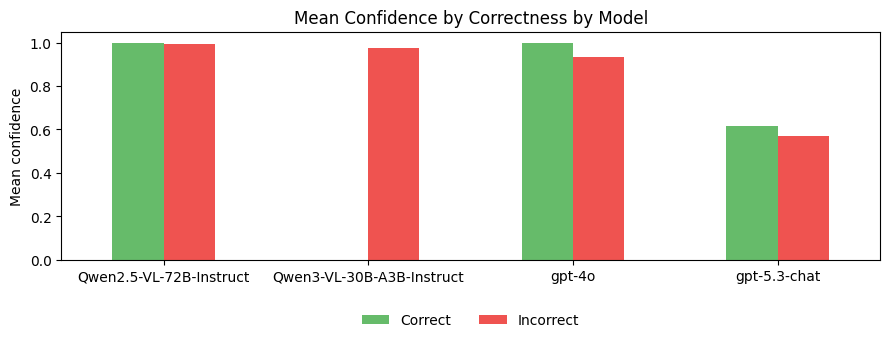

In [4]:
conf_df = df.dropna(subset=['overall_confidence']).copy()

confidence_by_correctness = (
    conf_df.groupby(['model_display', 'exact_move_match'], as_index=False)
    .agg(
        mean_confidence=('overall_confidence', 'mean'),
        samples=('overall_confidence', 'size'),
    )
)

confidence_by_correctness['correctness'] = confidence_by_correctness['exact_move_match'].map({
    True: 'Correct',
    False: 'Incorrect',
})

model_order = [
    model
    for model in benchmark_model_order
    if model in set(confidence_by_correctness['model_display'].astype(str))
]
confidence_by_correctness['model_display'] = pd.Categorical(
    confidence_by_correctness['model_display'],
    categories=model_order,
    ordered=True,
)

display(confidence_by_correctness.sort_values(['model_display', 'exact_move_match'], ascending=[True, False]))

pivot_df = (
    confidence_by_correctness
    .pivot(index='model_display', columns='correctness', values='mean_confidence')
    .fillna(0)
)
pivot_df = pivot_df.reindex(index=model_order)
pivot_df = pivot_df.reindex(columns=['Correct', 'Incorrect'])

ax = pivot_df.plot(
    kind='bar',
    figsize=(9, 4),
    color=['#66BB6A', '#EF5350'],
)
ax.set_title('Mean Confidence by Correctness by Model')
ax.set_ylabel('Mean confidence')
ax.set_xlabel('')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=0)
ax.legend(
    ['Correct', 'Incorrect'],
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=False,
)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


### External Benchmark Source Notes
- External columns use `MMMU` and `MathVista`.
- `Qwen2.5-VL-72B-Instruct` and `Qwen3-VL-30B-A3B-Instruct` values come from Qwen model-card benchmark tables.
- `gpt-4o` `MathVista=63.8` comes from the MathVista project news/leaderboard notes.
- `gpt-5.3-chat` `MMMU=73.8` uses a proxy from a published `gpt-5.3-instant` benchmark summary (same GPT-5.3 family, different serving variant).


## 4) Move Benchmark Diagnostics

These plots summarise the finished `benchmark_move` run: completion quality, overall move strength, and move-style tendencies.

In [5]:
move_data_dir = Path('data/benchmark_move')
move_details_path = move_data_dir / 'benchmark_move_details.csv'
move_summary_path = move_data_dir / 'benchmark_move_summary.csv'

move_df = pd.read_csv(move_details_path)
move_df['model_display'] = move_df['model'].str.replace(r'^Qwen/', '', regex=True)
move_df['is_success'] = move_df['error'].isna() | (move_df['error'].astype(str).str.strip() == '')

move_success_df = move_df[move_df['is_success']].copy()

print('Move benchmark rows:', len(move_df))
print('Successful rows:', int(move_df['is_success'].sum()))
print('Failed rows:', int((~move_df['is_success']).sum()))

error_top = (
    move_df.loc[~move_df['is_success'], 'error']
    .value_counts()
    .rename_axis('error')
    .reset_index(name='count')
)

display(error_top.head(5))


Move benchmark rows: 200
Successful rows: 200
Failed rows: 0


,error,count


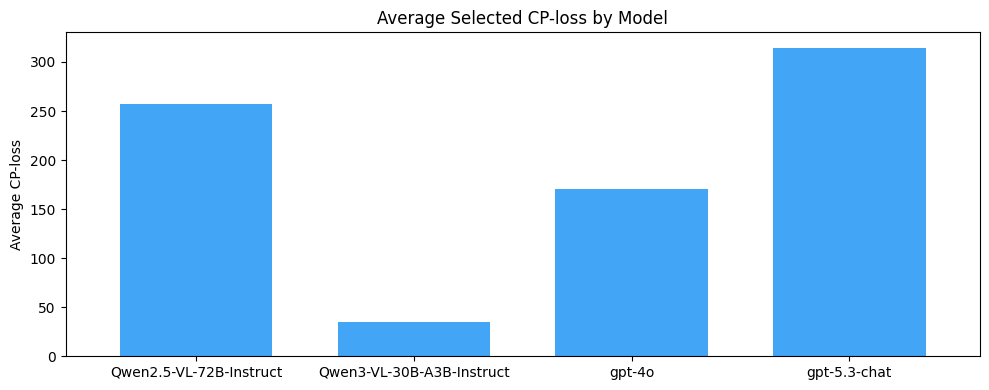

In [6]:
# 4.2 Average selected CP-loss by model (successful rows only)
cp_loss_by_model = (
    move_success_df.groupby('model_display', as_index=False)
    .agg(avg_selected_cp_loss=('selected_cp_loss', 'mean'))
)

model_order = [
    model
    for model in benchmark_model_order
    if model in set(cp_loss_by_model['model_display'].astype(str))
]
cp_loss_by_model['model_display'] = pd.Categorical(
    cp_loss_by_model['model_display'],
    categories=model_order,
    ordered=True,
)
cp_loss_by_model = cp_loss_by_model.sort_values('model_display')

ax = cp_loss_by_model.plot(
    kind='bar',
    x='model_display',
    y='avg_selected_cp_loss',
    figsize=(10, 4),
    width=0.7,
    legend=False,
    color='#42A5F5',
)
ax.set_title('Average Selected CP-loss by Model')
ax.set_xlabel('')
ax.set_ylabel('Average CP-loss')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


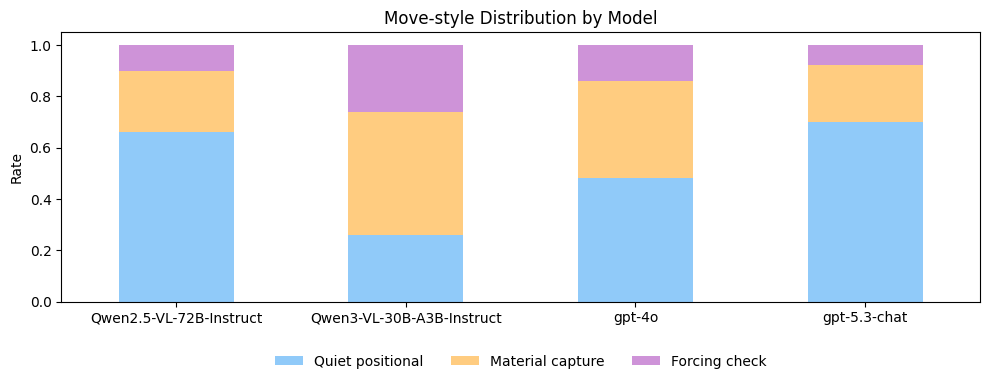

In [7]:
# 4.3 Move-style distribution by model (successful rows only)
style_dist = (
    move_success_df.groupby(['model_display', 'move_style'], as_index=False)
    .size()
    .rename(columns={'size': 'count'})
)
style_dist['rate'] = style_dist['count'] / style_dist.groupby('model_display')['count'].transform('sum')

style_order = ['quiet_positional', 'material_capture', 'forcing_check']
model_order = [
    model
    for model in benchmark_model_order
    if model in set(style_dist['model_display'].astype(str))
]
style_pivot = (
    style_dist.pivot(index='model_display', columns='move_style', values='rate')
    .fillna(0)
    .reindex(columns=style_order)
    .reindex(index=model_order)
)

ax = style_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 4),
    color=['#90CAF9', '#FFCC80', '#CE93D8'],
)
ax.set_title('Move-style Distribution by Model')
ax.set_xlabel('')
ax.set_ylabel('Rate')
ax.tick_params(axis='x', rotation=0)
ax.legend(['Quiet positional', 'Material capture', 'Forcing check'], loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
plt.tight_layout()
plt.show()
